In [12]:
!pip install -q import-ipynb  

import sys
import os


project_root = '/content/document-classifier'
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to sys.path")


import import_ipynb
from src.utils.connect_to_colab import setup_colab_environment, get_drive_path


vm_path = setup_colab_environment()
print(f"Project ready at: {vm_path}")

print("Data symlink exists?", os.path.islink(f"{vm_path}/data"))
print("Models symlink exists?", os.path.islink(f"{vm_path}/src/models/trained_models"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted
Already up to date.
Setup complete!
Project ready at: /content/document-classifier
Data symlink exists? True
Models symlink exists? True


In [13]:
# Create clean symlink & persistent copy to Drive
import os
import shutil

kaggle_cache_path = "/root/.cache/kagglehub/datasets/suvroo/scanned-images-dataset-for-ocr-and-vlm-finetuning/versions/1/dataset"

# Clean, short path we want to use everywhere
clean_data_path = "/content/document-classifier/data/scanned_docs"

#If Drive is mounted copy to Drive + symlink
if os.path.ismount('/content/drive'):
    drive_data_path = f"{get_drive_path()}/data/scanned_docs"
    if os.path.exists(kaggle_cache_path) and not os.path.exists(drive_data_path):
        print("Copying dataset to Drive for persistence...")
        shutil.copytree(kaggle_cache_path, drive_data_path)
        print("Copy done →", drive_data_path)
    else:
        print("Dataset already copied or not needed:", drive_data_path)

    # Now symlink the clean path to the Drive location
    if not os.path.islink(clean_data_path) and not os.path.exists(clean_data_path):
        !ln -sf {drive_data_path} {clean_data_path}
        print("Symlink created:", clean_data_path, "→ Drive/scanned_docs")

# if no Drive ,symlink to kagglehub cache (temporary)
else:
    if os.path.exists(kaggle_cache_path) and not os.path.exists(clean_data_path):
        !ln -sf {kaggle_cache_path} {clean_data_path}
        print("Symlink created (temporary):", clean_data_path, "→ kagglehub cache")

# Final path to use in the rest of the notebook
images_root = clean_data_path

print("\nUsing clean path from now on:", images_root)
print("Exists?", os.path.exists(images_root))
print("Is symlink?", os.path.islink(images_root))

Dataset already copied or not needed: /content/drive/MyDrive/ColabNotebooks/document-classifier/data/scanned_docs

Using clean path from now on: /content/document-classifier/data/scanned_docs
Exists? True
Is symlink? False


In [14]:
import kagglehub
import os

images_root = "/content/document-classifier/data/scanned_docs"

# Check if we already have the dataset
if os.path.exists(images_root) and len(os.listdir(images_root)) > 5:  # >5 to be sure it's not empty
    print("Dataset already available at:", images_root)
    print("Skipping download.")
else:
    print("Dataset not found, downloading now...")
    path = kagglehub.dataset_download("suvroo/scanned-images-dataset-for-ocr-and-vlm-finetuning")
    
    print("\nDownload & unzip complete!")
    print("Downloaded to temporary location:", path)

print("Number of class folders:", len([d for d in os.listdir(images_root) if os.path.isdir(os.path.join(images_root, d))]))

Dataset already available at: /content/document-classifier/data/scanned_docs
Skipping download.
Number of class folders: 10


Dataset root: /content/document-classifier/data/scanned_docs
Class folders: ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']
ADVE        :  230 images
Email       :  599 images
Form        :  431 images
Letter      :  567 images
Memo        :  620 images
News        :  188 images
Note        :  201 images
Report      :  265 images
Resume      :  120 images
Scientific  :  261 images

Total images: 3482

Showing one random sample per class (4-column grid):


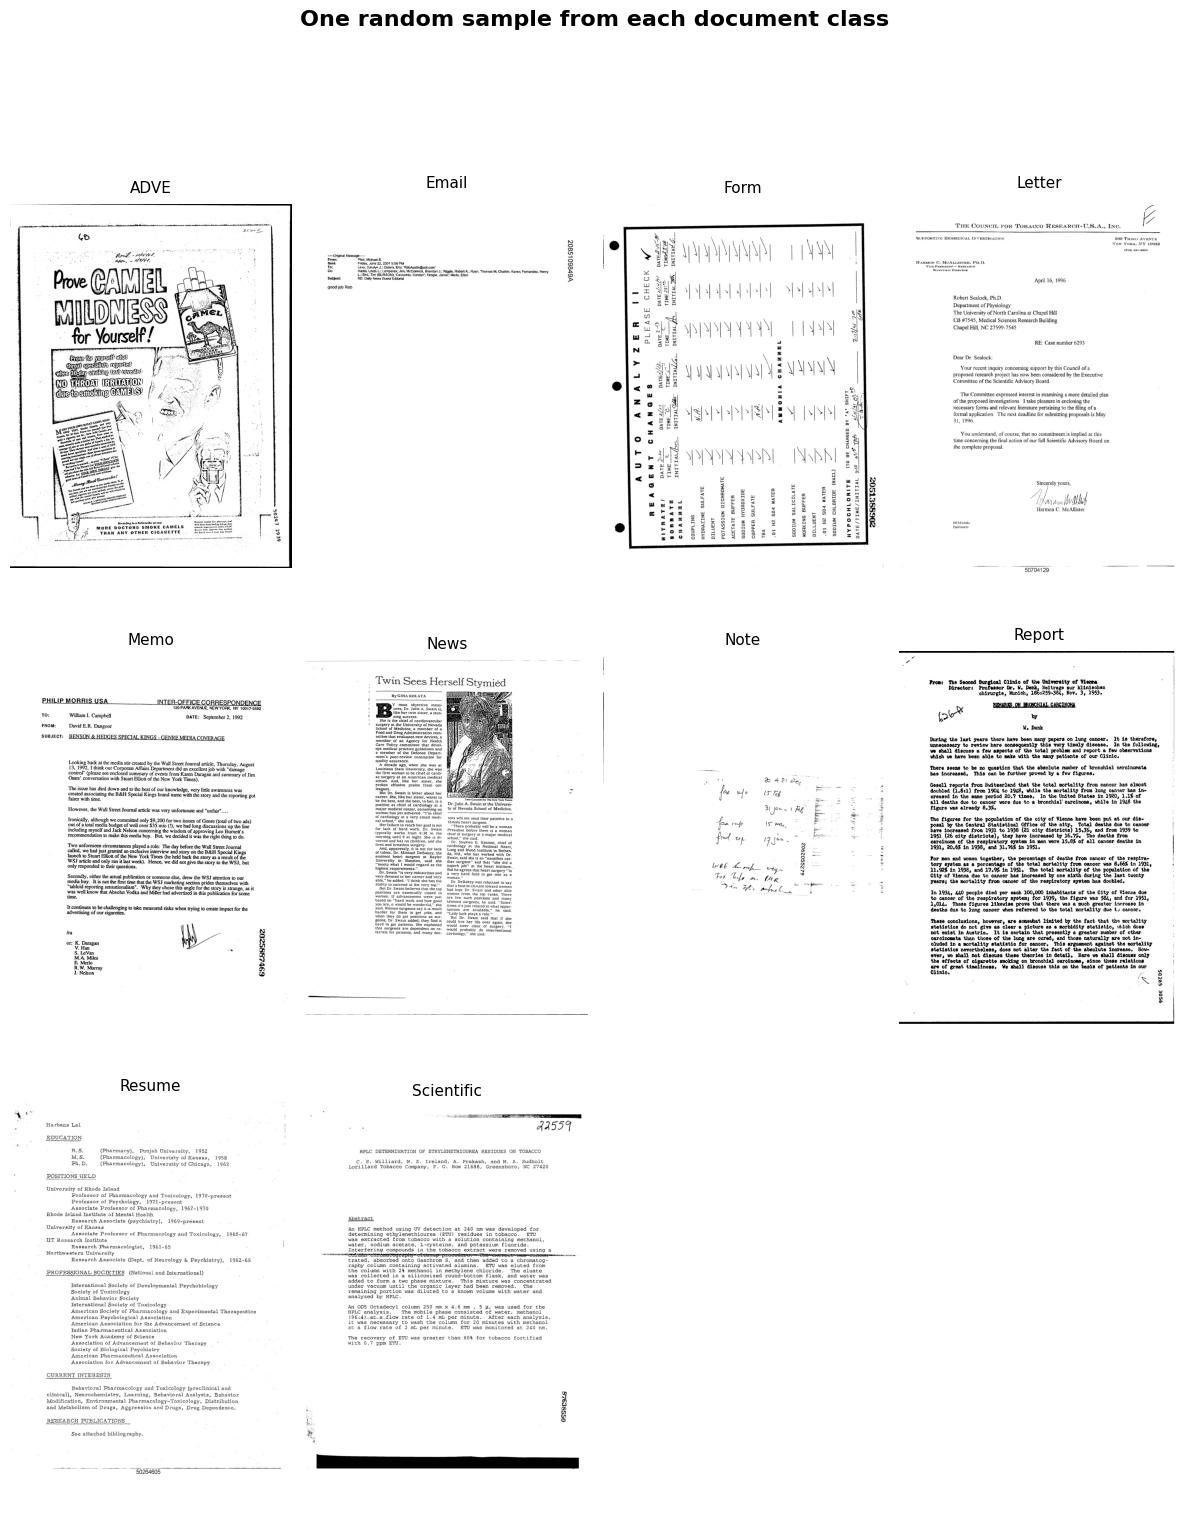

In [15]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

images_root = "/content/document-classifier/data/scanned_docs"

print("Dataset root:", images_root)
print("Class folders:", sorted(os.listdir(images_root)))

# Count images per class
class_counts = {}
for class_name in sorted(os.listdir(images_root)):
    class_path = os.path.join(images_root, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        count = len(images)
        if count > 0:
            class_counts[class_name] = count
            print(f"{class_name:12}: {count:4d} images")

total = sum(class_counts.values())
print(f"\nTotal images: {total}")

# Show ONE random image per class in a 4-column grid
def show_one_per_class():
    classes = sorted([cls for cls in class_counts.keys()])
    
    # Create a grid: 4 columns (10 classes, 3 full + 1 partial)
    cols = 4
    rows = (len(classes) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 5))
    fig.suptitle("One random sample from each document class", 
                 fontsize=16, fontweight='bold', y=1.02)
    
    axes_flat = axes.flatten()
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(images_root, class_name)
        images = [f for f in os.listdir(class_path) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if not images:
            axes_flat[i].text(0.5, 0.5, "No images", ha='center', va='center', color='gray')
            axes_flat[i].axis('off')
            continue
        
        # Pick one random image
        img_file = random.choice(images)
        full_path = os.path.join(class_path, img_file)
        
        try:
            img = Image.open(full_path)
            axes_flat[i].imshow(img, cmap='gray')
            axes_flat[i].axis('off')
            axes_flat[i].set_title(class_name, fontsize=11, pad=8)
        except Exception as e:
            axes_flat[i].text(0.5, 0.5, f"Error", ha='center', va='center', color='red')
            axes_flat[i].axis('off')
    
    # Hide empty subplots in the last row
    for j in range(len(classes), len(axes_flat)):
        axes_flat[j].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# Run the visualization
print("\nShowing one random sample per class (4-column grid):")
show_one_per_class()
 